# We optimize the GC for large coupling 

In this notebook we preform inverse design of the grating coupler design shown in "testing.ipynb"

In [5]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range,
                    to_substrate)


In [ ]:
# define the objective function
def objective(params,projection=lambda x: x):

    # project the parameters
    params_proj = projection(params)

    # unpack the projected parameters
    widths = params_proj[:-3]
    r0 = params_proj[-3]
    etch_depth = params_proj[-2]
    to_substrate = params_proj[-1]
    
    # run the simulation
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=False)
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False, path="/data/tidy3d_output/tmp.hdf5")
    coupling = get_coupling_efficiency(sim_data)
    return np.mean(coupling)

Now we will run an optimization. The project and inverse project functions allow us to add constriant by projecting the design parameters into a space where they cannot pass preset bounds. These are defined in "main.py"

In [6]:
# define the initial parameters
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor, N_teeth=N_teeth, grating_period=grating_period)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

# define the projection for enforcing constraints
project, inverse_project = projection_builder()

# run the optimization
history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=35, learning_rate=0.01, verbose=True)

step = 1
	J = 3.427e-01
	grad_norm = 4.6534e-01
step = 2
	J = 3.519e-01
	grad_norm = 4.6064e-01
step = 3
	J = 3.713e-01
	grad_norm = 4.5085e-01
step = 4
	J = 3.806e-01
	grad_norm = 4.4381e-01
step = 5
	J = 3.886e-01
	grad_norm = 4.3773e-01
step = 6
	J = 3.970e-01
	grad_norm = 4.3337e-01
step = 7
	J = 4.048e-01
	grad_norm = 4.2928e-01
step = 8
	J = 4.127e-01
	grad_norm = 4.2629e-01
step = 9
	J = 4.216e-01
	grad_norm = 4.2256e-01
step = 10
	J = 4.306e-01
	grad_norm = 4.1948e-01
step = 11
	J = 4.406e-01
	grad_norm = 4.1643e-01
step = 12
	J = 4.510e-01
	grad_norm = 4.1370e-01
step = 13
	J = 4.625e-01
	grad_norm = 4.1167e-01
step = 14
	J = 4.734e-01
	grad_norm = 4.0896e-01
step = 15
	J = 4.884e-01
	grad_norm = 4.1557e-01
step = 16
	J = 4.968e-01
	grad_norm = 4.1496e-01
step = 17
	J = 5.055e-01
	grad_norm = 4.1605e-01
step = 18
	J = 5.148e-01
	grad_norm = 4.1604e-01
step = 19
	J = 5.241e-01
	grad_norm = 4.1579e-01
step = 20
	J = 5.325e-01
	grad_norm = 4.1808e-01
step = 21
	J = 5.412e-01
	gra

In [9]:
# save history and opt state in a pickle file
with open('data/opt/history.pkl', 'wb') as f:
    pickle.dump({'history': history, 'opt_state': opt_state}, f)

# Analysis

Compare the final and initial designs

In [11]:
# define the initial simulation
sim_initial = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=True)

# pull out the final parameters
widths_final = history["params"][-1][:-3]
r0_final = history["params"][-1][-3]
etch_depth_final = history["params"][-1][-2]
to_substrate_final = history["params"][-1][-1]

#define the final simulation 
sim_final = make_sim(widths_final, r0=r0_final, etch_depth=etch_depth_final, to_substrate=to_substrate_final, include_field_monitor=True)

#run the two simulations 
sim_data_initial = web.run(sim_initial, task_name="GC4um_2D_initial_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")
sim_data_final = web.run(sim_final, task_name="GC4um_2D_final_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")

#compute the coupling efficiencies 
ce_initial = get_coupling_efficiency(sim_data_initial)
ce_final = get_coupling_efficiency(sim_data_final)

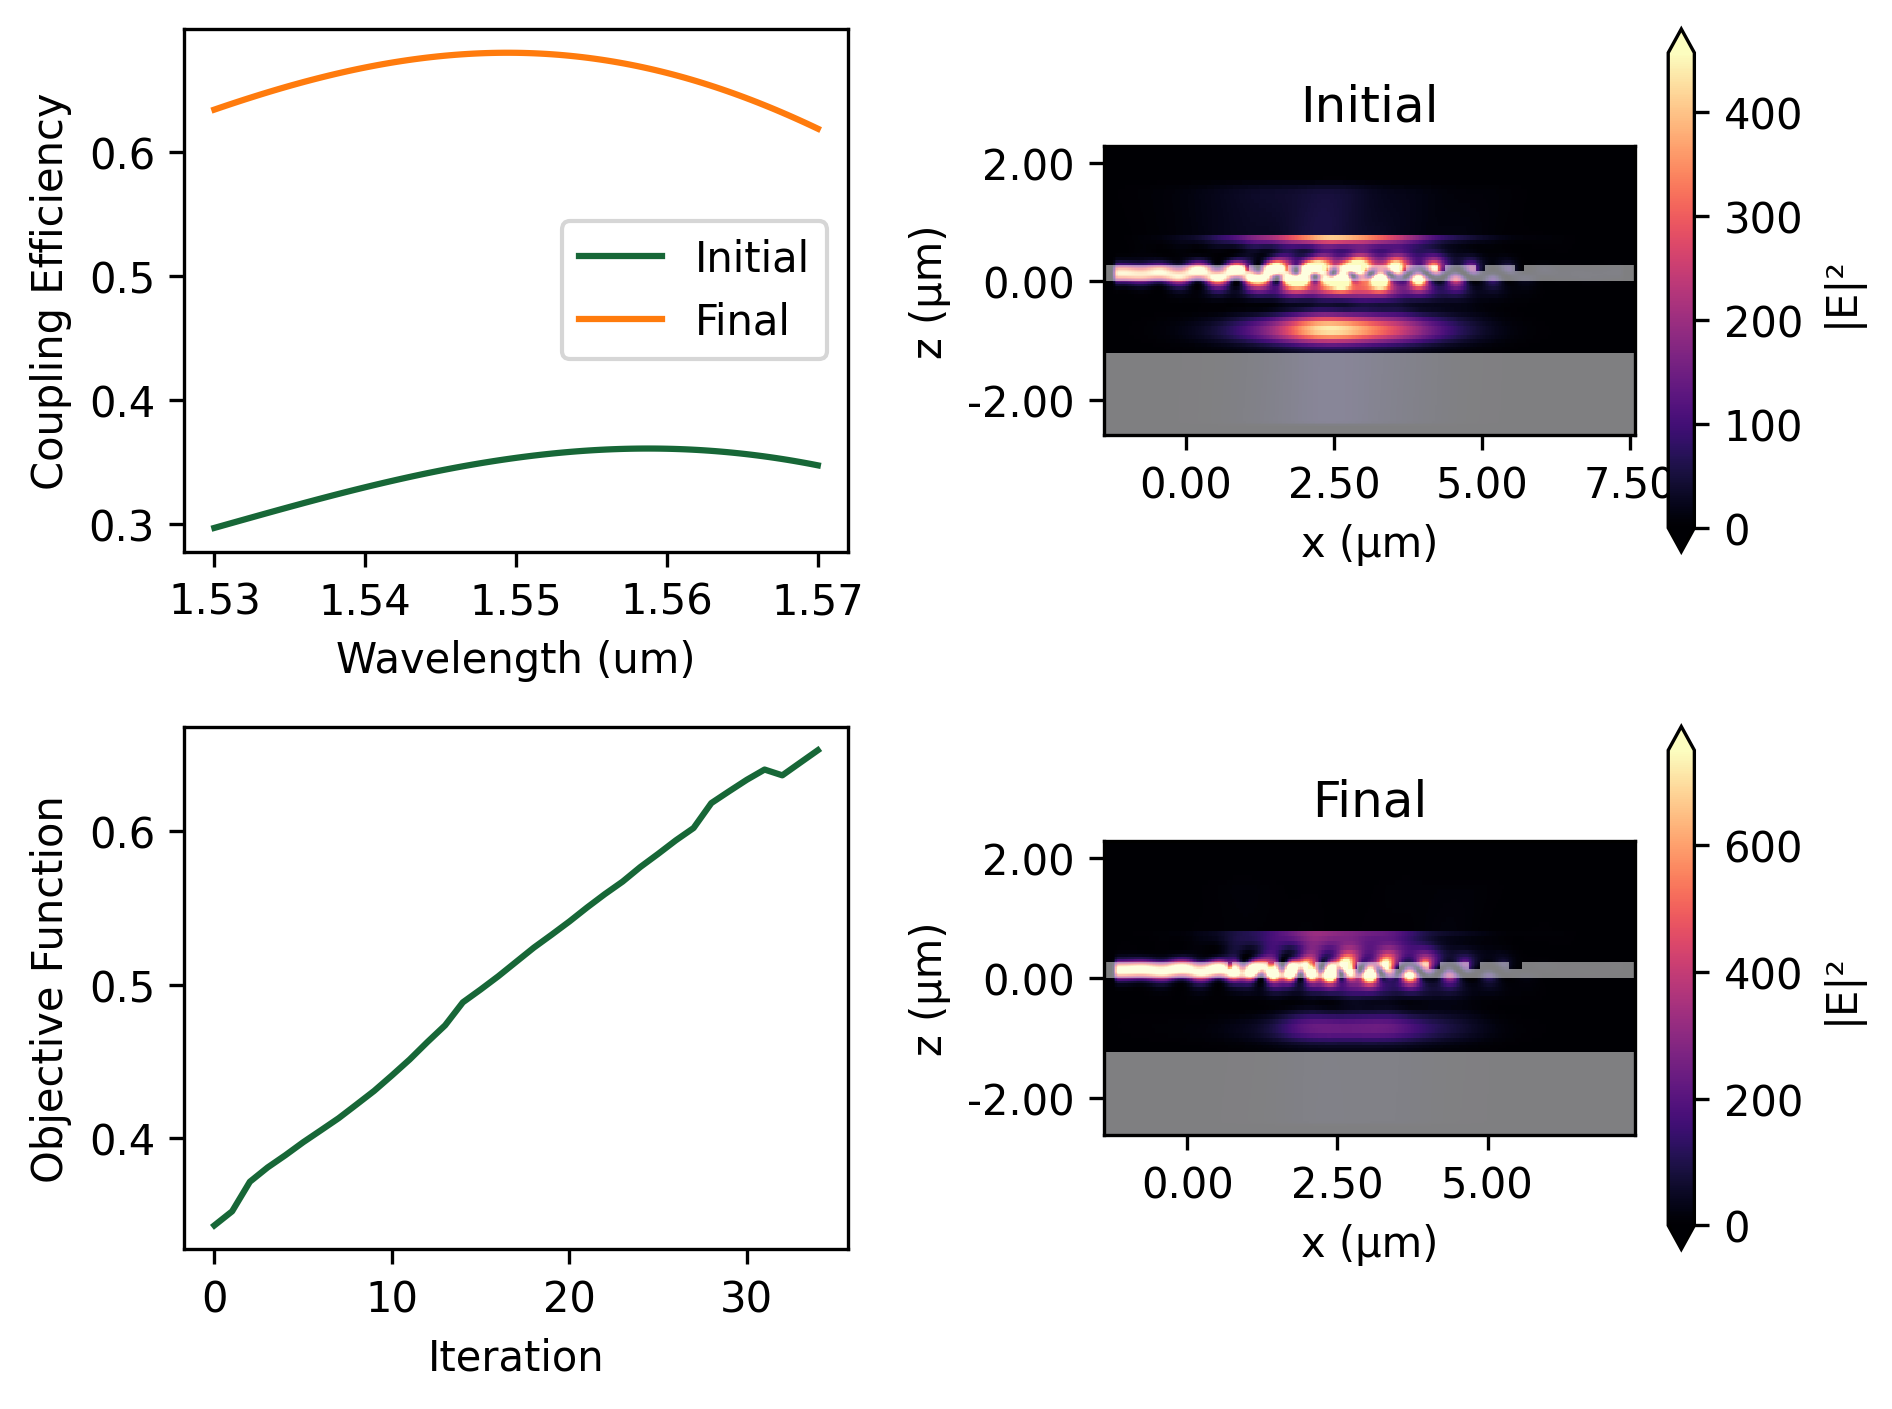

In [16]:
fig,ax = plt.subplots(2,2,dpi=300)

#plot the coupling efficiencies 
ax[0,0].plot(wl_range, ce_initial,label="Initial")
ax[0,0].plot(wl_range, ce_final,label="Final")
ax[0,0].set_xlabel("Wavelength (um)")
ax[0,0].set_ylabel("Coupling Efficiency")
ax[0,0].legend()

#plot the field monitors 
sim_data_initial.plot_field("field", "E", "abs^2", y=0, ax=ax[0,1],eps_alpha=0.5)
ax[0,1].set_title("Initial")
sim_data_final.plot_field("field", "E", "abs^2", y=0, ax=ax[1,1],eps_alpha=0.5)
ax[1,1].set_title("Final")

# plot the change in the objective function 
ax[1,0].plot(history["J"])
ax[1,0].set_xlabel("Iteration")
ax[1,0].set_ylabel("Objective Function")

plt.tight_layout()
plt.show()

# Conclusion

We could continue to optimize the structure and likely continue to see imrovments, but we will stop here and use it as a seed for the 3D design.